<a href="https://colab.research.google.com/github/Steven10P/Analisis-KDM-PNC/blob/main/notebooks/04a_SVHN_KDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# BLOQUE 1: MLOps - Entorno, Drive, KDM y Repo
# ==========================================
import os
import sys
from google.colab import drive

# 1. CONEXIÓN A DRIVE Y GITHUB (Vía token seguro)
print("--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---")
drive.mount('/content/drive', force_remount=True)
CARPETA_DRIVE = '/content/drive/MyDrive/01.Maestria/MLOps'

# Aseguramos que el script de setup esté en el path
if CARPETA_DRIVE not in sys.path:
    sys.path.append(CARPETA_DRIVE)

import setup_env

# Esto lee el token y clona/actualiza el repo automáticamente
setup_env.init_project(drive_token_path=f"{CARPETA_DRIVE}/github_token.txt")

# 2. CONFIGURACIÓN DEL REPOSITORIO PRINCIPAL
REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

# 3. INSTALACIÓN DE DEPENDENCIAS EXTERNAS (KDM)
print("\n--- INSTALANDO LIBRERÍA KDM ---")
os.chdir('/content')
if not os.path.exists('/content/kdm'):
    !git clone https://github.com/fagonzalezo/kdm.git /content/kdm

!pip install -q -e /content/kdm

# Limpiar path por si acaso y añadir KDM al principio
if '/content/kdm' in sys.path: sys.path.remove('/content/kdm')
sys.path.insert(0, '/content/kdm')

# 4. CORRECCIÓN DE BUGS DE ENTORNO (Refresco mágico)
!pip install -q --upgrade scikit-learn scipy
import site
site.main()

# Importaciones base necesarias para el resto del notebook
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Volvemos al repositorio para trabajar desde allí
os.chdir(REPO_PATH)
print(f"\n[✅] Entorno MLOps configurado perfectamente. Directorio actual: {os.getcwd()}")

--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---
Mounted at /content/drive
🚀 Iniciando configuración del entorno MLOps...
[*] Clonando el repositorio Analisis-KDM-PNC...
[*] Directorio de trabajo establecido en: /content/Analisis-KDM-PNC
[*] Credenciales de Git configuradas.

[✅ ÉXITO] Entorno listo. Ya puedes importar módulos de Analisis-KDM-PNC.

--- INSTALANDO LIBRERÍA KDM ---
Cloning into '/content/kdm'...
remote: Enumerating objects: 558, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 558 (delta 33), reused 36 (delta 26), pack-reused 502 (from 1)
Receiving objects: 100% (558/558), 61.81 MiB | 29.45 MiB/s, done.
Resolving deltas: 100% (328/328), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for kdm (pyproject.toml) ... done
     ━

In [2]:
# ==========================================
# BLOQUE 2: CARGA DE DATOS Y CONFIGURACIÓN (KDM - FASHION)
# ==========================================
import yaml
import sys
import os
import numpy as np # <--- AGREGADO: Necesario para np.unique al final

# 1. Importar tus módulos personalizados del repositorio
REPO_PATH = "/content/Analisis-KDM-PNC"
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

# CAMBIO CLAVE: Importar la clase de Fashion que creamos
from src.data.dataset_loaders import SVHNDatasetLoader
# 2. Cargar Configuración desde el archivo YAML
# Asegúrate de que la ruta coincida exactamente con la ubicación de tu YAML
PATH_CONFIG = os.path.join(REPO_PATH, 'configs/svhn/kdm.yaml')

print(f"[INFO] Leyendo configuración desde: {PATH_CONFIG}")
with open(PATH_CONFIG, 'r') as f:
    config_global = yaml.safe_load(f)

# Extraer parámetros específicos para facilidad de uso
params_grid = config_global.get('grid_search', {}).get('param_grid', {})
print(f"[✅] Configuración cargada. Espacio de búsqueda: {params_grid}")

[INFO] Leyendo configuración desde: /content/Analisis-KDM-PNC/configs/svhn/kdm.yaml
[✅] Configuración cargada. Espacio de búsqueda: {'n_comp': [256, 512], 'encoded_size': [128, 256], 'lr': [0.001, 0.0005], 'sigma': [0.5, 1.0]}


In [3]:
REPO_PATH

'/content/Analisis-KDM-PNC'

In [4]:
# ==========================================
# BLOQUE 3: INICIALIZACIÓN DEL PIPELINE (SVHN)
# ==========================================
import numpy as np

print("\n[INFO] Iniciando Pipeline de datos para SVHN...")

# 1. Instanciar el cargador con la ruta estándar de la tesis
# Usamos flatten_input=True porque el KDM espera vectores para el Kernel
pipeline = SVHNDatasetLoader(data_dir=f'{REPO_PATH}/data/svhn', flatten_input=True)

# 2. Carga de datos (usando el método load_data que definimos en la clase)
X_train_full, y_train_full, X_test, y_test = pipeline.load_data()

# 3. Verificación de Integridad y Dimensionalidad
# SVHN debe reportar 3072 dimensiones (32x32x3)
print("-" * 40)
print(f"RESUMEN DE CARGA (KDM - SVHN):")
print(f"  - Registros Entrenamiento: {X_train_full.shape[0]}")
print(f"  - Registros Test:          {X_test.shape[0]}")
print(f"  - Dimensiones (Flatten):   {X_train_full.shape[1]} (32x32x3)")
print(f"  - Clases (0-9):            {y_train_full.shape[1] if y_train_full.ndim > 1 else 'LabelEncoded'}")
print("-" * 40)

# Verificación visual rápida del rango de píxeles (debe ser [0, 1])
if X_train_full.max() > 1.0:
    print("[⚠️] Alerta: Los datos no parecen estar normalizados.")
else:
    print("[✅] Normalización verificada.")


[INFO] Iniciando Pipeline de datos para SVHN...
[⬇️] Descargando partición train de SVHN...
[⬇️] Descargando partición test de SVHN...
[⚙️] Procesando y transponiendo tensores SVHN...
----------------------------------------
RESUMEN DE CARGA (KDM - SVHN):
  - Registros Entrenamiento: 73257
  - Registros Test:          26032
  - Dimensiones (Flatten):   3072 (32x32x3)
  - Clases (0-9):            10
----------------------------------------
[✅] Normalización verificada.


In [5]:
params_grid

{'n_comp': [256, 512],
 'encoded_size': [128, 256],
 'lr': [0.001, 0.0005],
 'sigma': [0.5, 1.0]}

In [6]:
# ==========================================
# BLOQUE 3: GRID SEARCH ESTRATÉGICO - SVHN (MLOps Ready - V2)
# ==========================================
import itertools
import time
import pandas as pd
import numpy as np
import yaml
import os
from sklearn.model_selection import KFold
# IMPORTANTE: Importamos la V2 que es la que tiene lógica dinámica
from src.models.kdm_factory_v2 import build_kdm_model_v2

# 1. Configuración de Rutas Dinámicas (SVHN)
REPO_PATH = os.getcwd() # Asegurar que REPO_PATH esté definido
output_path = os.path.join(REPO_PATH, "resultados/svhn")
os.makedirs(f"{output_path}/metricas", exist_ok=True)
os.makedirs(f"{output_path}/modelos", exist_ok=True)

ruta_mejores_params = f"{output_path}/metricas/best_kdm_params.yaml"
ruta_historial_csv = f"{output_path}/metricas/gridsearch_history.csv"

# 2. Verificación de Persistencia
if os.path.exists(ruta_mejores_params):
    print(f"[⏩] Salto de búsqueda: Configuración encontrada en {ruta_mejores_params}")
    with open(ruta_mejores_params, 'r') as file:
        mejor_config = yaml.safe_load(file)
    print(f"[INFO] Parámetros cargados: {mejor_config}")
else:
    print(f"[⏳] Iniciando Grid Search SVHN (Dim de entrada: {X_train_full.shape[1]})...")

    # Submuestreo para agilizar experimentos de tesis
    SAMPLE_FRACTION = 0.33
    np.random.seed(42)
    idx_sample = np.random.choice(len(X_train_full), int(len(X_train_full) * SAMPLE_FRACTION), replace=False)
    X_sample, y_sample = X_train_full[idx_sample], y_train_full[idx_sample]

    # Generación de la cuadrícula
    keys, values = zip(*params_grid.items())
    grid_configs = [dict(zip(keys, v)) for v in itertools.product(*values)]

    resultados_grid = []
    mejor_val_acc = 0.0
    mejor_config = None

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    start_grid_time = time.time()

    for idx, conf in enumerate(grid_configs):
        print(f"\n--- Probando Configuración {idx+1}/{len(grid_configs)}: {conf} ---")
        fold_accs = []
        start_conf_time = time.time()

        for fold, (t_idx, v_idx) in enumerate(kf.split(X_sample)):
            x_t, y_t = X_sample[t_idx], y_sample[t_idx]
            x_v, y_v = X_sample[v_idx], y_sample[v_idx]

            # LLAMADA A LA V2: Aquí es donde se soluciona el error de compatibilidad
            # build_kdm_model_v2 detectará automáticamente los 3072 de SVHN
            modelo, total_params = build_kdm_model_v2(conf, x_t, y_t)

            hist = modelo.fit(
                x_t, y_t,
                validation_data=(x_v, y_v),
                epochs=5,
                batch_size=128,
                verbose=0
            )

            acc_f = hist.history['val_accuracy'][-1]
            fold_accs.append(acc_f)
            print(f"  Fold {fold+1} Acc: {acc_f:.4f}")

        # Registro de métricas
        mean_acc = np.mean(fold_accs)
        time_elapsed = time.time() - start_conf_time

        registro = {**conf,
                    'mean_val_acc': float(mean_acc),
                    'std_val_acc': float(np.std(fold_accs)),
                    'total_params': int(total_params),
                    'search_time_sec': float(time_elapsed)}

        resultados_grid.append(registro)

        if mean_acc > mejor_val_acc:
            mejor_val_acc = mean_acc
            mejor_config = conf.copy()

    # 3. Guardado MLOps
    df_res = pd.DataFrame(resultados_grid).sort_values(by='mean_val_acc', ascending=False)
    df_res.to_csv(ruta_historial_csv, index=False)

    with open(ruta_mejores_params, 'w') as f:
        yaml.dump(mejor_config, f)

    print(f"\n[✅] Búsqueda finalizada en {time.time() - start_grid_time:.1f}s")
    print(f"[🏆] Mejor Acc en SVHN: {mejor_val_acc:.4f}")

/content/kdm/kdm/utils.py:186: SyntaxWarning: invalid escape sequence '\p'
  Calculates the overlap of a state  \phi(x) with a density


[⏳] Iniciando Grid Search SVHN (Dim de entrada: 3072)...

--- Probando Configuración 1/16: {'n_comp': 256, 'encoded_size': 128, 'lr': 0.001, 'sigma': 0.5} ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  
  Fold 1 Acc: 0.1902
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
  Fold 2 Acc: 0.1888
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
  Fold 3 Acc: 0.1932

--- Probando Configuración 2/16: {'n_comp': 256, 'encoded_size': 128, 'lr': 0.001, 'sigma': 1.0} ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
  Fold 1 Acc: 0.1902
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
  Fold 2 Acc: 0.1888
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
  Fold 3 Acc: 0.1932

--- Probando Configuración 3/16: {'n_comp': 256, 'encoded_size': 128, 'lr': 0.0005, 'sigma': 0.5} ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
  Fold 1 Acc: 0.1902
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
  Fold 2 Acc: 0.1888
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
  Fold 3 Acc: 0.1932

--- Probando Configuración 4/16: {'n_comp': 256, 'encoded_size': 128, 'lr': 0.0005, 'sigma': 1.0} ---
8

In [10]:
1

1

In [8]:
# ==========================================
# BLOQUE 4 y 5: ENTRENAMIENTO FINAL Y EVALUACIÓN (SVHN - V2)
# ==========================================
import os
import yaml
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
# IMPORTANTE: Usamos la factoría V2 para soporte dinámico de 3072 dims
from src.models.kdm_factory_v2 import build_kdm_model_v2

# 1. Cargar la mejor configuración guardada para SVHN
# Cambiamos la ruta de fashion a svhn
ruta_base_svhn = os.path.join(REPO_PATH, "resultados/svhn")
ruta_mejores_params = f"{ruta_base_svhn}/metricas/best_kdm_params.yaml"

print("--- INICIANDO ENTRENAMIENTO DEFINITIVO SVHN ---")
if not os.path.exists(ruta_mejores_params):
    raise FileNotFoundError(f"❌ No se encontró {ruta_mejores_params}. Ejecuta el Bloque 3 primero.")

with open(ruta_mejores_params, 'r') as file:
    mejor_config = yaml.safe_load(file)
print(f"[INFO] Configuración campeona para SVHN: {mejor_config}")

# 2. Split de Validación (10%)
# X_train_full ya tiene forma (N, 3072) gracias al SVHNDatasetLoader
X_t, X_v, y_t, y_v = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42)

# 3. Construir el modelo final con la Factoría V2
# build_kdm_model_v2 detectará automáticamente las 3072 dimensiones
modelo_final, total_params = build_kdm_model_v2(mejor_config, X_train_full, y_train_full)
print(f"[INFO] Parámetros totales del modelo KDM final: {total_params}")

# 4. Entrenamiento a fondo
EPOCHS_FINALES = 10
start_time = time.time()

# El fit funcionará correctamente porque la V2 ya ajustó la pérdida (loss)
history = modelo_final.fit(
    X_t, y_t,
    validation_data=(X_v, y_v),
    epochs=EPOCHS_FINALES,
    batch_size=128,
    verbose=1
)

tiempo_entrenamiento = time.time() - start_time
print(f"\n[✅] Entrenamiento SVHN finalizado en {tiempo_entrenamiento:.2f} segundos.")

# 5. Predicción para métricas
print("[⏳] Generando predicciones sobre el conjunto de test...")
y_pred = modelo_final.predict(X_test)

--- INICIANDO ENTRENAMIENTO DEFINITIVO SVHN ---
[INFO] Configuración campeona para SVHN: {'encoded_size': 128, 'lr': 0.001, 'n_comp': 256, 'sigma': 0.5}
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[INFO] Parámetros totales del modelo KDM final: 1674625.0
Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.1882 - loss: 2.2557 - val_accuracy: 0.1994 - val_loss: 2.2374
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.1881 - loss: 2.2556 - val_accuracy: 0.1994 - val_loss: 2.2374
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.1881 - loss: 2.2556 - val_accuracy: 0.1994 - val_loss: 2.2374
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.1881 - loss: 2.2556 - val_accuracy: 0.1994 - val_loss: 2.2374
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.1881 - loss: 2.2556 - val_accuracy: 0.1994 - val_loss: 2.2374
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.1881 - loss: 2.2556 - val_accurac

In [11]:

# ==========================================
# EVALUACIÓN, GRÁFICAS Y GUARDADO (MLOps)
# ==========================================
os.makedirs(f"{ruta_base_svhn}/modelos", exist_ok=True)
os.makedirs(f"{ruta_base_svhn}/graficas", exist_ok=True)

print("\n--- GENERANDO PREDICCIONES Y MÉTRICAS DE TEST ---")
# 5. Predicciones en el conjunto de Test real (10,000 imágenes nunca antes vistas)
y_pred = np.argmax(modelo_final.predict(X_test), axis=1)


--- GENERANDO PREDICCIONES Y MÉTRICAS DE TEST ---
814/814 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step



--- GENERANDO PREDICCIONES Y MÉTRICAS PARA SVHN ---
814/814 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



[✅] Evaluación finalizada. Resultados guardados en: /content/Analisis-KDM-PNC/resultados/svhn


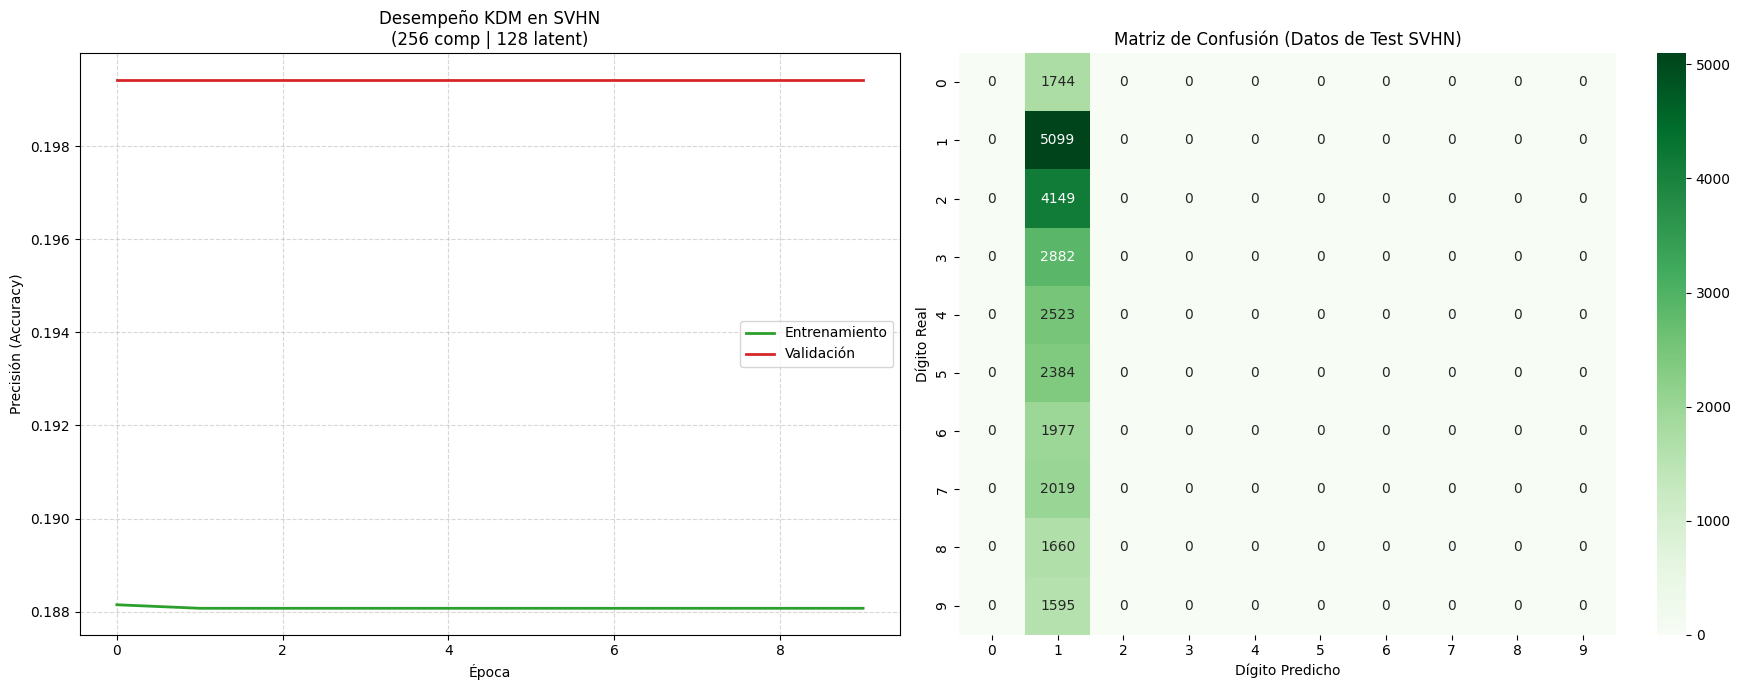

In [12]:
# ==========================================
# BLOQUE 6: EVALUACIÓN, GRÁFICAS Y GUARDADO (SVHN)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Definición de etiquetas reales para SVHN (Números del 0 al 9)
nombres_clases_svhn = [str(i) for i in range(10)]

# Asegurar que las rutas apunten a la carpeta de SVHN definida anteriormente
os.makedirs(f"{ruta_base_svhn}/modelos", exist_ok=True)
os.makedirs(f"{ruta_base_svhn}/graficas", exist_ok=True)

print("\n--- GENERANDO PREDICCIONES Y MÉTRICAS PARA SVHN ---")

# 2. Predicciones: Convertimos las probabilidades del modelo a índices de clase
raw_predictions = modelo_final.predict(X_test)
y_pred_idx = np.argmax(raw_predictions, axis=1)

# 3. Ajuste de etiquetas reales:
# Si y_test es One-Hot (viniendo de SVHNDatasetLoader), lo pasamos a índices
y_test_idx = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

# 4. Creación de visualizaciones de desempeño
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfica A: Curvas de Aprendizaje ---
ax[0].plot(history.history['accuracy'], label='Entrenamiento', color='#2ca02c', linewidth=2)
ax[0].plot(history.history['val_accuracy'], label='Validación', color='#d62728', linewidth=2)
ax[0].set_title(f'Desempeño KDM en SVHN\n({mejor_config["n_comp"]} comp | {mejor_config["encoded_size"]} latent)', fontsize=12)
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Precisión (Accuracy)')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfica B: Matriz de Confusión ---
cm = confusion_matrix(y_test_idx, y_pred_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=nombres_clases_svhn, yticklabels=nombres_clases_svhn)
ax[1].set_title('Matriz de Confusión (Datos de Test SVHN)', fontsize=12)
ax[1].set_xlabel('Dígito Predicho')
ax[1].set_ylabel('Dígito Real')

plt.tight_layout()

# ==========================================
# BLOQUE 7: PERSISTENCIA DE RESULTADOS (MLOps)
# ==========================================

# Guardar los pesos finales del modelo entrenado
ruta_pesos = f"{ruta_base_svhn}/modelos/kdm_svhn_final.weights.h5"
modelo_final.save_weights(ruta_pesos)

# Guardar reporte de métricas por clase (Precision, Recall, F1)
report = classification_report(y_test_idx, y_pred_idx, target_names=nombres_clases_svhn, output_dict=True)
pd.DataFrame(report).transpose().to_csv(f"{ruta_base_svhn}/metricas/reporte_svhn_kdm.csv")

# Guardar la gráfica para el documento de la tesis
fig.savefig(f"{ruta_base_svhn}/graficas/visualizacion_svhn_final.png", dpi=300, bbox_inches='tight')

print(f"\n[✅] Evaluación finalizada. Resultados guardados en: {ruta_base_svhn}")
plt.show()

In [13]:
# ==========================================
# BLOQUE 6: SINCRONIZACIÓN CON GITHUB (MLOps)
# ==========================================
import os

# 1. Asegurarnos de estar en la raíz del repositorio
REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)

print("--- PREPARANDO SINCRONIZACIÓN CON GITHUB ---")

# 2. Configurar credenciales temporales de Git para Colab
# (Cámbialo por tu correo de GitHub real si lo prefieres)
!git config --global user.email "bspd1007@gmail.com"
!git config --global user.name "bspd1007 (Google Colab)"

# 3. Revisar el estado actual de los archivos
print("\n[INFO] Archivos listos para ser versionados:")
!git status -s

# 4. Agregar únicamente los resultados de MNIST
!git add resultados/svhn/

# 5. Crear el Commit con un mensaje descriptivo y científico
MENSAJE_COMMIT = "feat(KDM): Entrenamiento definitivo SVHMo"
!git commit -m "{MENSAJE_COMMIT}"

# 6. Enviar los cambios al repositorio remoto
print("\n[INFO] Haciendo push a GitHub...")
# Nota: Si tu rama principal se llama 'master' en lugar de 'main', cambia la siguiente línea.
!git push origin main

print("\n[✅] ¡Trazabilidad asegurada! Tus pesos (.h5), métricas y gráficas están a salvo en el repositorio.")

--- PREPARANDO SINCRONIZACIÓN CON GITHUB ---

[INFO] Archivos listos para ser versionados:
?? resultados/svhn/graficas/visualizacion_svhn_final.png
?? resultados/svhn/metricas/best_kdm_params.yaml
?? resultados/svhn/metricas/gridsearch_history.csv
?? resultados/svhn/metricas/reporte_svhn_kdm.csv
[main b881381] feat(KDM): Entrenamiento definitivo SVHMo
 4 files changed, 35 insertions(+)
 create mode 100644 resultados/svhn/graficas/visualizacion_svhn_final.png
 create mode 100644 resultados/svhn/metricas/best_kdm_params.yaml
 create mode 100644 resultados/svhn/metricas/gridsearch_history.csv
 create mode 100644 resultados/svhn/metricas/reporte_svhn_kdm.csv

[INFO] Haciendo push a GitHub...
To https://github.com/Steven10P/Analisis-KDM-PNC.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/Steven10P/Analisis-KDM-PNC.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually ca

In [14]:
# ==========================================
# BLOQUE DE RESCATE: FORZAR SUBIDA DEL MODELO
# ==========================================
import os

REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)

print("--- DIAGNÓSTICO LOCAL ---")
# 1. Verificamos que el archivo físico esté en el Colab
!ls -lh resultados/svhn/modelos/

print("\n--- FORZANDO LA INSERCIÓN A GIT ---")
# 2. El parámetro -f (force) obliga a Git a ignorar el .gitignore
!git add -f resultados/SVHN/modelos/kdm_best_model.weights.h5

# Verificamos si Git ahora sí lo tiene en la mira
!git status -s

# 3. Nuevo commit y push
!git commit -m "fix(KDM): Forzando la subida de los pesos del modelo .h5 ignorando .gitignore"
!git push origin main

print("\n[✅] Rescate finalizado. Revisa tu GitHub ahora, el archivo .h5 debería estar allí.")

--- DIAGNÓSTICO LOCAL ---
total 20M
-rw-r--r-- 1 root root 20M Apr  9 15:58 kdm_svhn_final.weights.h5

--- FORZANDO LA INSERCIÓN A GIT ---
fatal: pathspec 'resultados/SVHN/modelos/kdm_best_model.weights.h5' did not match any files
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
To https://github.com/Steven10P/Analisis-KDM-PNC.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/Steven10P/Analisis-KDM-PNC.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.

[✅] Rescate finalizado. Revisa tu GitHub ahora, el archivo .h5 debería estar